# **Unzip the Dataset**

In [1]:
import os, zipfile

In [2]:
zip_path = "/content/data.zip"
extract_to = "/content"

In [3]:
import os, zipfile
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Done! Files extracted to:", extract_to)

Done! Files extracted to: /content


In [4]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import binary_opening, binary_closing, label
from dataclasses import dataclass
from typing import Optional, Tuple

# Helper Functions

In [5]:
def _normalize(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    if n < 1e-12:
        return v
    return v / n

In [6]:
def plane_from_3_points(p1: np.ndarray, p2: np.ndarray, p3: np.ndarray) -> Optional[Tuple[np.ndarray, float]]:
    u, v = p2 - p1, p3 - p1
    n = np.cross(u, v)
    nn = np.linalg.norm(n)
    if nn < 1e-12:
        return None
    n = n / nn
    d = -float(np.dot(n, p1))
    return n, d

In [7]:
def point_plane_distances(points: np.ndarray, n: np.ndarray, d: float) -> np.ndarray:
    """|n·x + d| with n assumed unit length."""
    return np.abs(points @ n + d)

In [8]:
def imshow_single(img, title, cmap="viridis"):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
def scatter3(points: np.ndarray, title: str, c_by: Optional[np.ndarray] = None, s=0.5):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    if c_by is None:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=s)
    else:
        sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=s, c=c_by, cmap="viridis")
        fig.colorbar(sc, ax=ax, shrink=0.6)
    ax.set_title(title)
    plt.show()

In [10]:
def pca_xy_extent(xy: np.ndarray) -> Tuple[float, float]:

    if xy.shape[0] < 3:
        return 0.0, 0.0
    c = xy.mean(axis=0, keepdims=True)
    X = xy - c
    # SVD on covariance-equivalent matrix
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    R = Vt  # rows are principal axes
    Xp = X @ R.T
    mins = Xp.min(axis=0)
    maxs = Xp.max(axis=0)
    extents = np.abs(maxs - mins)  # [extent along PC1, extent along PC2]
    L, W = float(max(extents)), float(min(extents))
    return L, W

# RANSAC Implimentation

In [11]:


@dataclass
class RansacConfig:
    threshold: float = 0.01           # ε: inlier distance threshold (meters)
    max_iterations: int = 800
    early_exit_frac: float = 0.92
    seed: Optional[int] = 0
    target_normal: Optional[np.ndarray] = None
    min_cos_with_target: float = 0.95
    # ---- MLESAC additions ----
    score_mode: str = "ransac"        # "ransac" or "mlesac"
    gamma: Optional[float] = None     # outlier penalty (γ > ε); defaults to 1.5 * threshold


def ransac_plane(points: np.ndarray, cfg: RansacConfig) -> Optional[Tuple[np.ndarray, float, np.ndarray]]:
    """
    Plane fitting via RANSAC or MLESAC, controlled by cfg.score_mode.

    RANSAC : maximize inlier count (binary 0/1 score per point)
    MLESAC : minimize total cost where each point contributes
                d(s)  if d(s) < ε   (inlier -> its actual distance)
                γ     otherwise     (outlier -> constant penalty, γ > ε)
    """
    if points.shape[0] < 3:
        return None

    rng = np.random.default_rng(cfg.seed)
    N = points.shape[0]

    # γ for MLESAC (must be > ε)
    gamma = cfg.gamma if cfg.gamma is not None else 1.5 * cfg.threshold
    if cfg.score_mode == "mlesac" and gamma <= cfg.threshold:
        raise ValueError(f"MLESAC needs gamma > threshold (got gamma={gamma}, ε={cfg.threshold})")

    best_inliers = np.array([], dtype=int)
    best_model   = None
    best_cost    = np.inf   # MLESAC: lower is better

    for _ in range(cfg.max_iterations):
        idx = rng.choice(N, size=3, replace=False)
        p1, p2, p3 = points[idx]
        model = plane_from_3_points(p1, p2, p3)
        if model is None:
            continue

        n, d = model
        # Optional normal constraint (e.g. top plane parallel to floor)
        if cfg.target_normal is not None:
            cosang = abs(float(np.dot(n, cfg.target_normal)))
            if cosang < cfg.min_cos_with_target:
                continue

        dists       = point_plane_distances(points, n, d)
        inlier_mask = dists < cfg.threshold
        inliers     = np.where(inlier_mask)[0]

        # ---- Scoring ----
        if cfg.score_mode == "mlesac":
            # eq. (2):  Σ d_i (inliers)  +  γ · (#outliers)
            cost     = float(dists[inlier_mask].sum() + gamma * (N - inliers.size))
            improved = cost < best_cost
        else:  # "ransac"
            improved = inliers.size > best_inliers.size

        if improved:
            best_inliers = inliers
            best_model   = (n, d)
            if cfg.score_mode == "mlesac":
                best_cost = cost
            # Early exit when the current best already explains most of the data
            if best_inliers.size >= cfg.early_exit_frac * N:
                break

    if best_model is None:
        return None

    # Final SVD refinement on the chosen inlier set (unchanged from your version)
    pts = points[best_inliers]
    c   = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - c, full_matrices=False)
    n_ref = _normalize(Vt[-1])
    d_ref = -float(np.dot(n_ref, c))

    return n_ref, d_ref, best_inliers

# Main Pipeline

In [12]:
def detect_box_size(
    file_path: str,
    amplitude_key: str,
    distance_key: str,
    cloud_key: str,
    title: str = "Estimation"
):
    print(f"\n=== {title} ===")

    # ---- Load MAT ----
    data = scipy.io.loadmat(file_path)
    if amplitude_key not in data or distance_key not in data or cloud_key not in data:
        raise KeyError("One or more MAT keys not found. Check the provided keys.")

    A = np.squeeze(data[amplitude_key])   # amplitude image
    D = np.squeeze(data[distance_key])    # distance image
    PC = data[cloud_key]                  # H × W × 3

    H, W, C = PC.shape
    assert C == 3, "PC must be H×W×3"

    # ---- Visualize A, D (registered with PC) ----
    imshow_single(A, "Amplitude")
    imshow_single(np.clip(D, 0, 2.0), "Distance (clipped 0..2 m)")

    # ---- Valid mask (z != 0) ----
    valid_mask = PC[:, :, 2] != 0
    valid_points = PC[valid_mask]  # K × 3

    if valid_points.shape[0] < 100:
        print("Too few valid points; aborting.")
        return

    # ---- Quick 3D preview (subsample for speed) ----
    step = max(1, int(np.sqrt(valid_points.shape[0] / 120000)))  # try to keep <=120k points
    preview_pts = valid_points[::step]
    scatter3(preview_pts, "3D Point Cloud (valid)", c_by=preview_pts[:, 2])

    # ---- Floor RANSAC ----
    # floor_cfg = RansacConfig(threshold=0.01, max_iterations=800, early_exit_frac=0.92, seed=0)
    floor_cfg = RansacConfig(threshold=0.01, max_iterations=800, seed=0,
                         score_mode="mlesac", gamma=0.015)   # ε=0.01, γ=0.015
    floor_fit = ransac_plane(valid_points, floor_cfg)
    if floor_fit is None:
        print("Floor plane not found.")
        return
    floor_n, floor_d, floor_inliers_idx = floor_fit

    # ---- Visualize floor inliers ----
    floor_inliers_pts = valid_points[floor_inliers_idx]
    scatter3(floor_inliers_pts, "Floor Plane Inliers (RANSAC)")

    # ---- Build floor mask image (K -> H×W), then morphologically clean ----
    floor_mask_flat = np.zeros(valid_points.shape[0], dtype=np.uint8)
    floor_mask_flat[floor_inliers_idx] = 1
    floor_mask_image = np.zeros_like(valid_mask, dtype=np.uint8)
    floor_mask_image[valid_mask] = floor_mask_flat

    # Morphological cleanup (opening/closing)
    st = np.ones((3, 3), dtype=bool)
    floor_mask_bool = floor_mask_image.astype(bool)
    floor_mask_bool = binary_opening(floor_mask_bool, structure=st, iterations=1)
    floor_mask_bool = binary_closing(floor_mask_bool, structure=st, iterations=1)
    floor_mask_image = floor_mask_bool.astype(np.uint8)

    imshow_single(floor_mask_image, "Floor Mask (cleaned)", cmap="gray")

    # ---- Non-floor points ----
    non_floor_mask = valid_mask & (~floor_mask_bool)
    non_floor_points = PC[non_floor_mask]
    if non_floor_points.shape[0] < 100:
        print("Too few non-floor points; aborting.")
        return

    # ---- Top-plane RANSAC constrained to be ~parallel to floor ----
    top_cfg = RansacConfig(
        threshold=0.01, max_iterations=1200, early_exit_frac=0.92, seed=1,
        target_normal=floor_n, min_cos_with_target=0.97  # stricter parallelism
    )
    top_fit = ransac_plane(non_floor_points, top_cfg)
    if top_fit is None:
        print("Top plane not found.")
        return
    top_n, top_d, top_inliers_idx = top_fit

    # Align normals to point same general direction
    if np.dot(floor_n, top_n) < 0:
        top_n, top_d = -top_n, -top_d

    # ---- Visualize top inliers (use SAME array used in RANSAC!) ----
    top_inliers_pts = non_floor_points[top_inliers_idx]
    scatter3(top_inliers_pts, "Top Plane Inliers (RANSAC)")

    # ---- Build top mask image -> largest connected component ----
    top_mask_flat = np.zeros(non_floor_points.shape[0], dtype=np.uint8)
    top_mask_flat[top_inliers_idx] = 1
    top_mask_image = np.zeros_like(valid_mask, dtype=np.uint8)
    top_mask_image[non_floor_mask] = top_mask_flat

    # Connected components (8-connectivity)
    st2 = np.ones((3, 3), dtype=int)
    labeled, num_features = label(top_mask_image, structure=st2)
    if num_features == 0:
        print("No connected component found on the top mask.")
        return
    counts = np.bincount(labeled.ravel())
    counts[0] = 0  # background
    largest_label = int(np.argmax(counts))
    box_top_mask = (labeled == largest_label)

    imshow_single(box_top_mask.astype(np.uint8), "Box Top (Largest Connected Component)", cmap="gray")

    # ---- Dimensions ----
    # Height: distance between parallel planes (|d2 - d1|; normals are unit + aligned)
    height_m = abs(top_d - floor_d)  # n is unit, so no division needed

    # Length/Width from PCA on XY of the largest component points
    box_top_points = PC[box_top_mask]
    if box_top_points.shape[0] < 5:
        print("Not enough points in top component to measure L/W.")
        return
    xy = box_top_points[:, :2]  # use X,Y in meters
    L_m, W_m = pca_xy_extent(xy)

    # ---- Report (in cm) ----
    print("Estimated Box Size:")
    print(f"  Height: {height_m * 100:.2f} cm")
    print(f"  Length: {L_m * 100:.2f} cm")
    print(f"  Width : {W_m * 100:.2f} cm")


=== Estimation of 1st Data Set ===


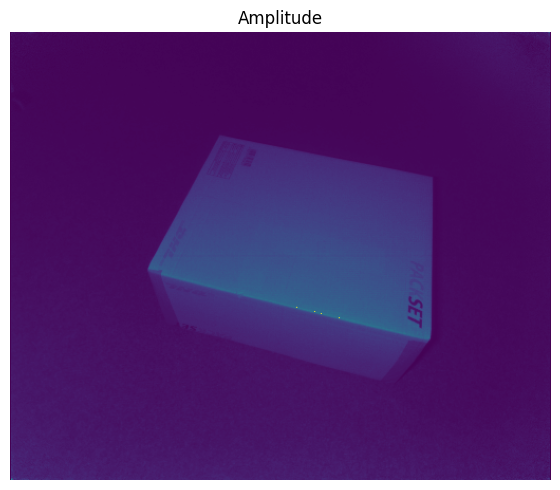

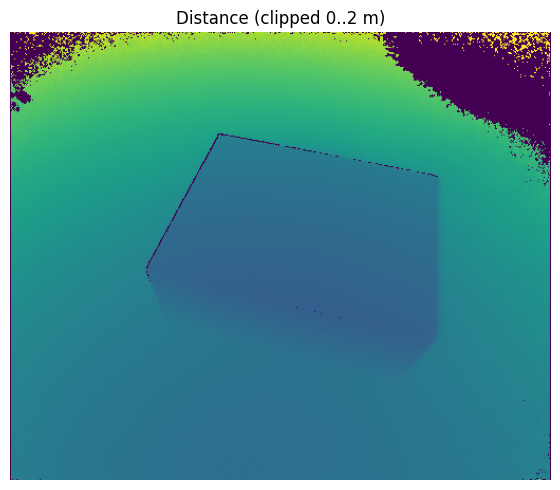

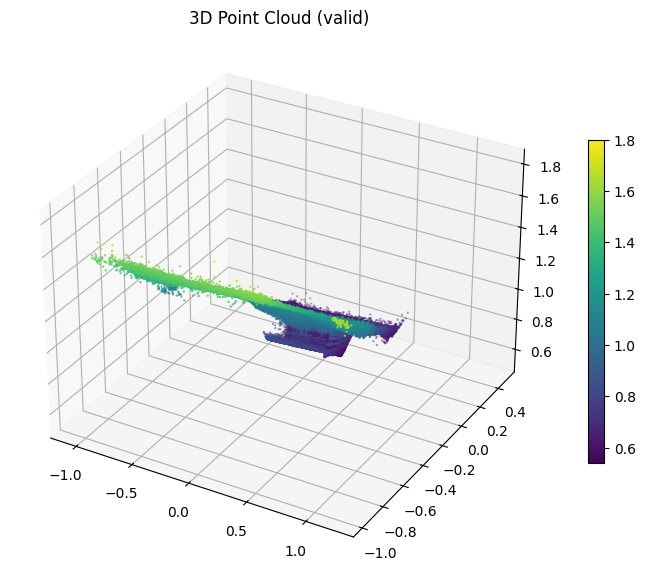

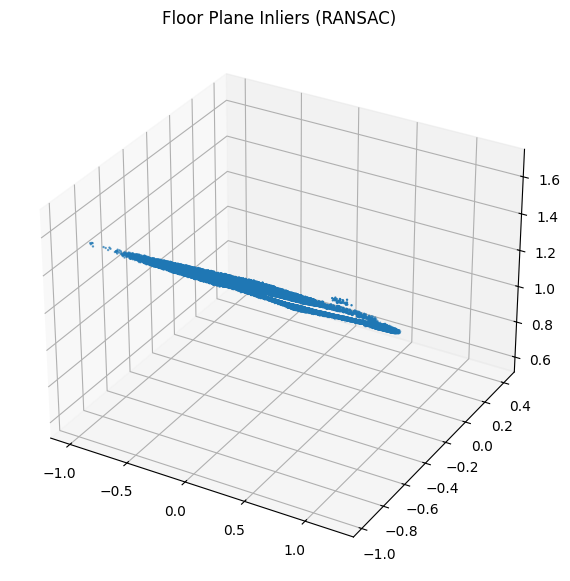

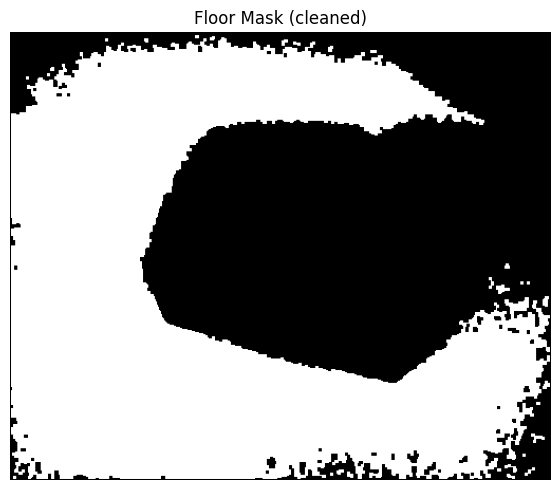

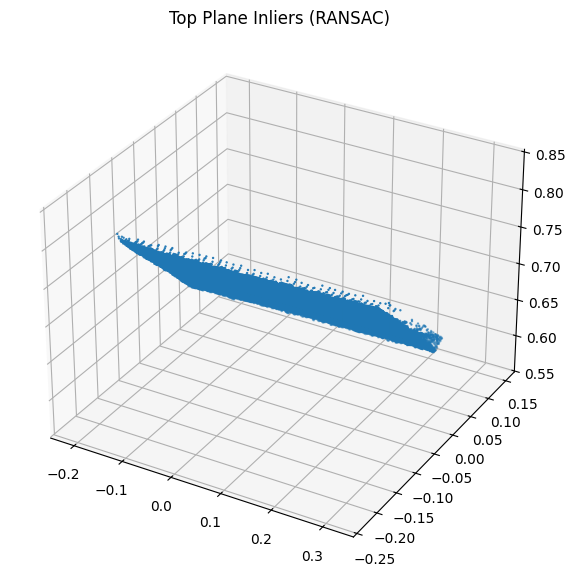

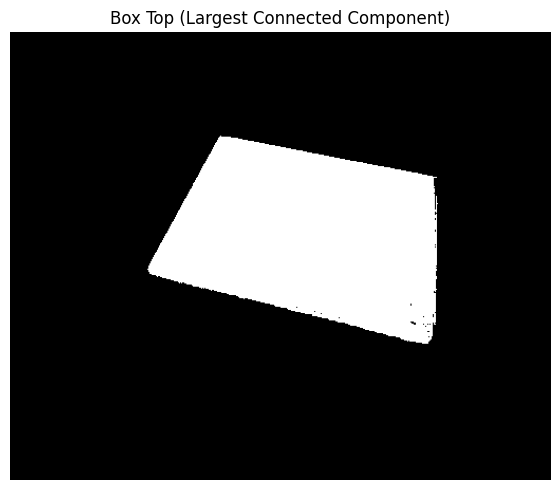

Estimated Box Size:
  Height: 19.44 cm
  Length: 49.12 cm
  Width : 31.62 cm

=== Estimation of 2nd Data Set ===


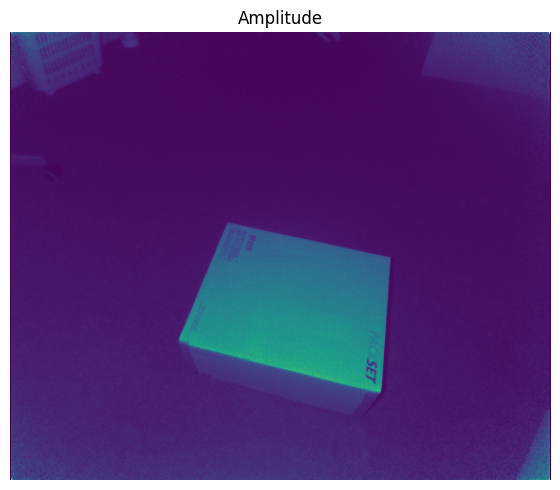

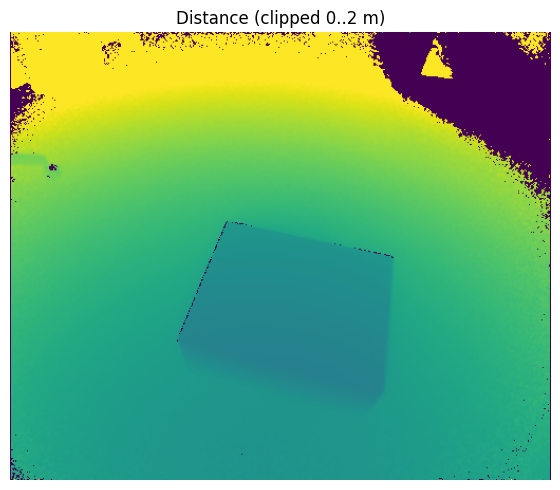

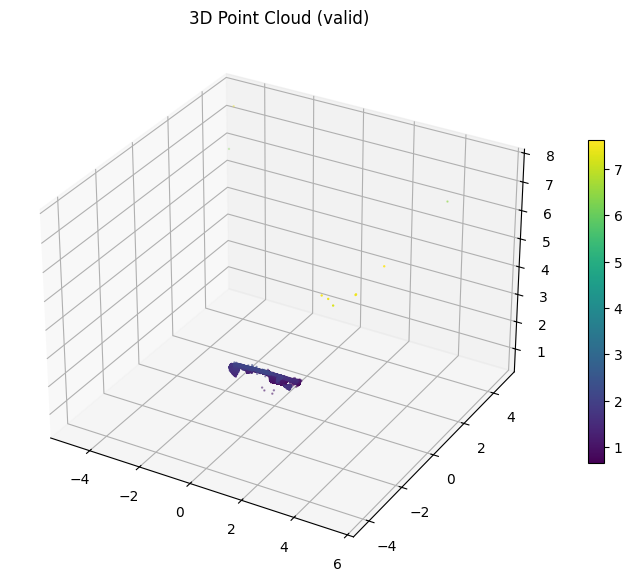

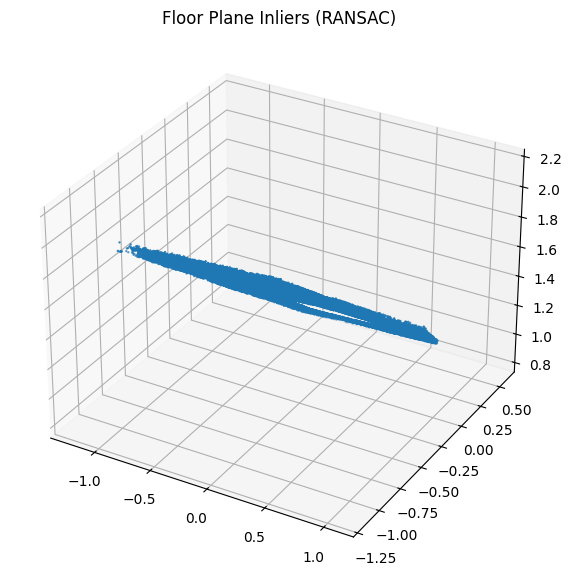

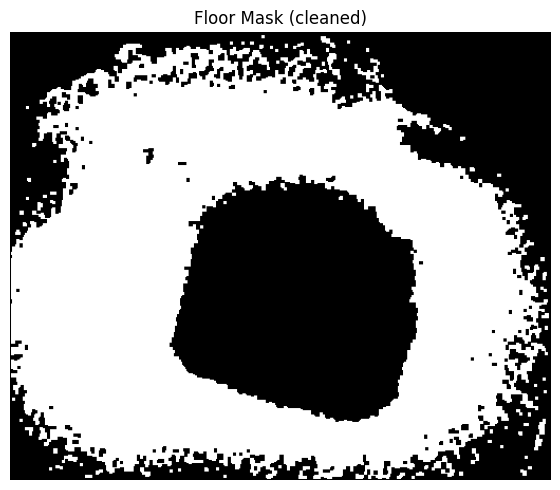

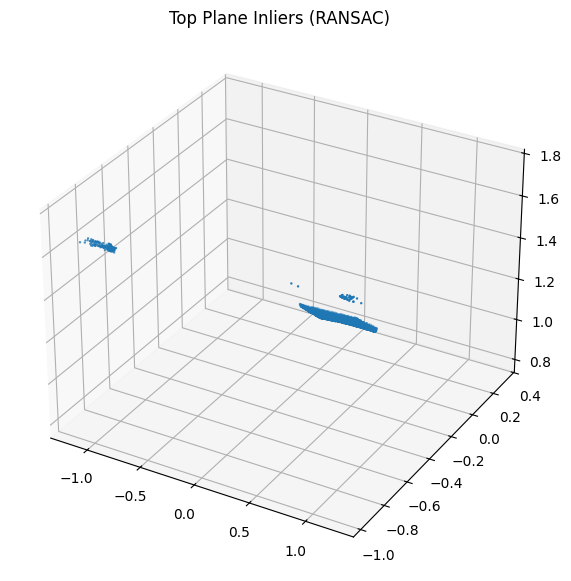

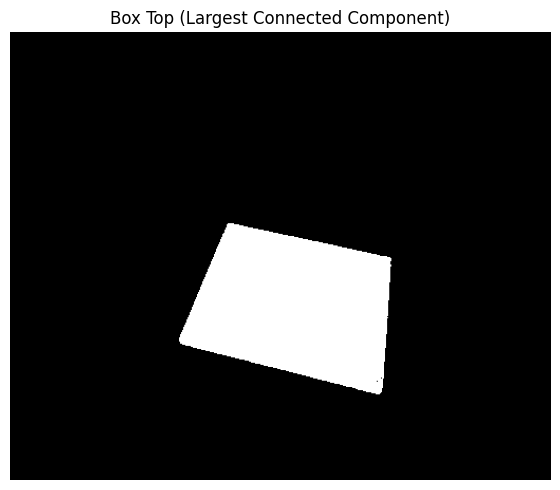

Estimated Box Size:
  Height: 18.81 cm
  Length: 48.04 cm
  Width : 31.16 cm

=== Estimation of 3rd Data Set ===


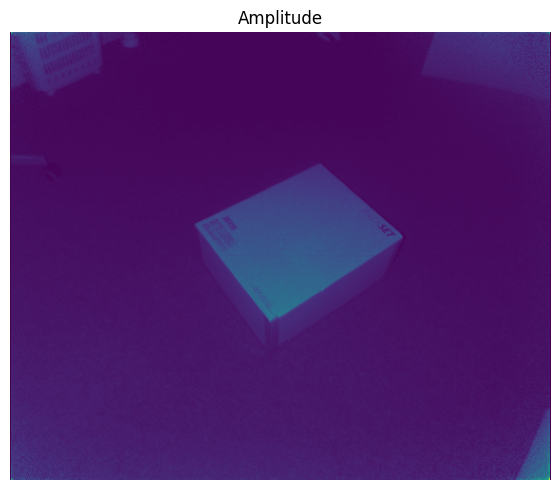

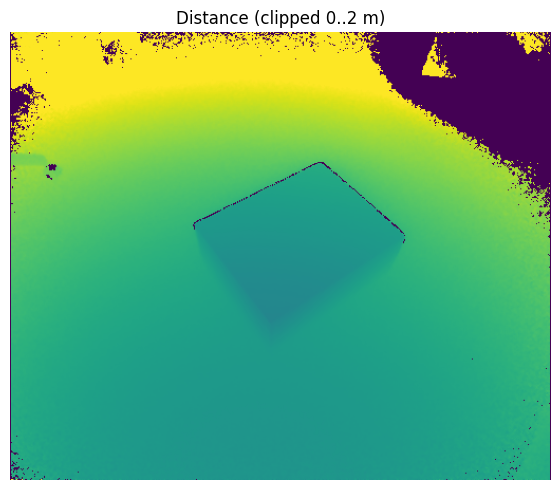

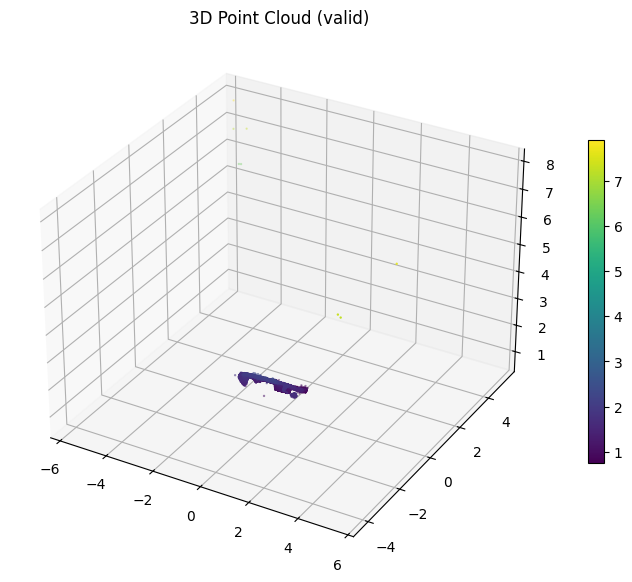

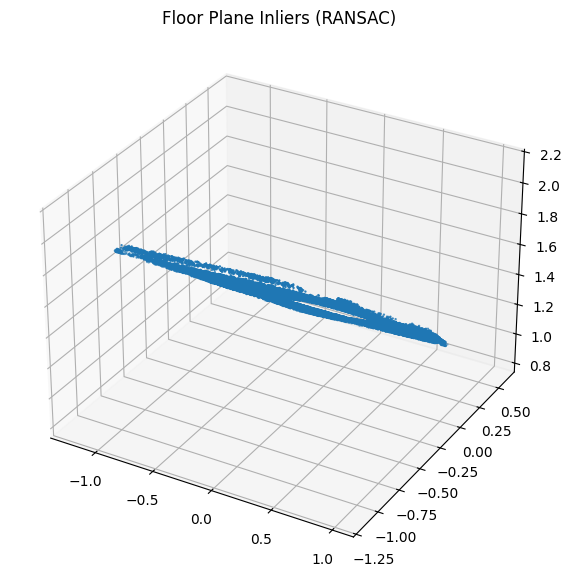

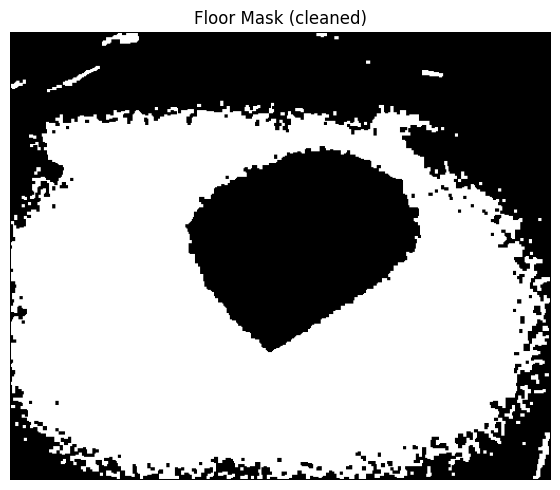

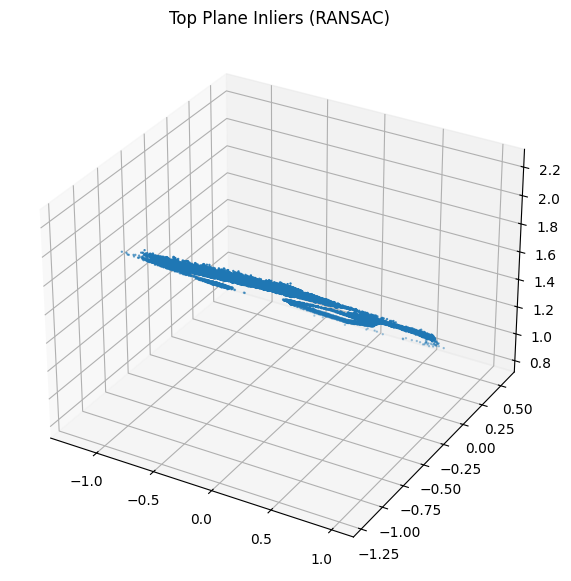

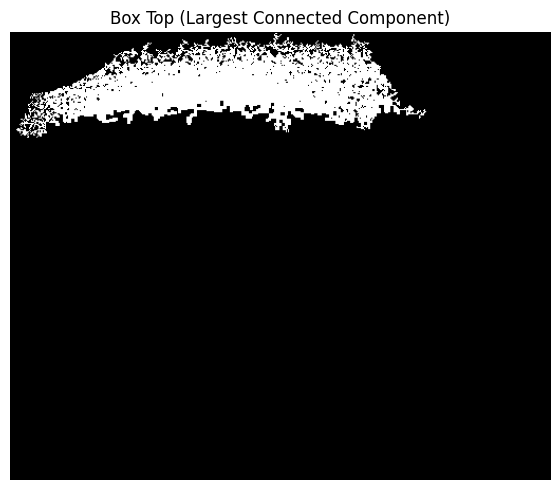

Estimated Box Size:
  Height: 5.27 cm
  Length: 176.33 cm
  Width : 71.37 cm

=== Estimation of 4th Data Set ===


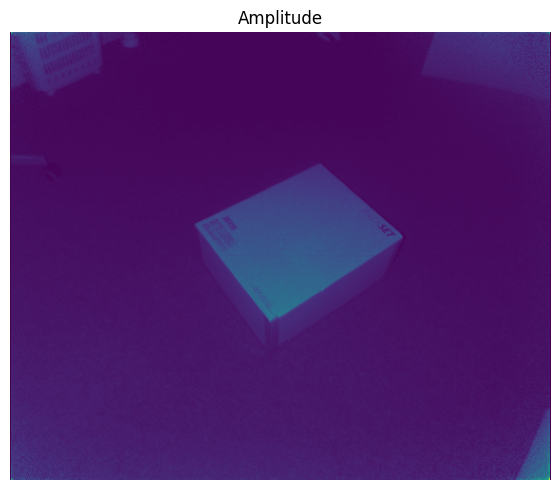

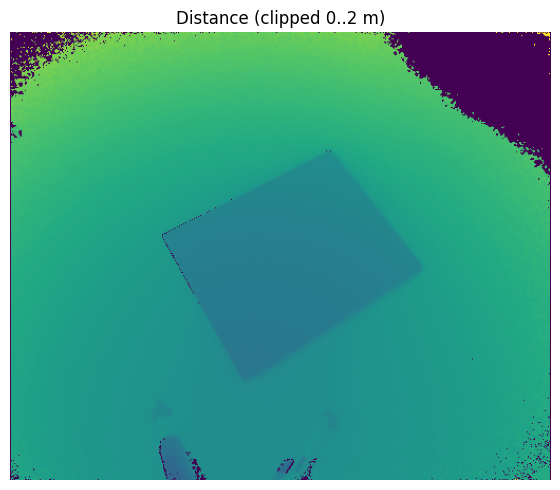

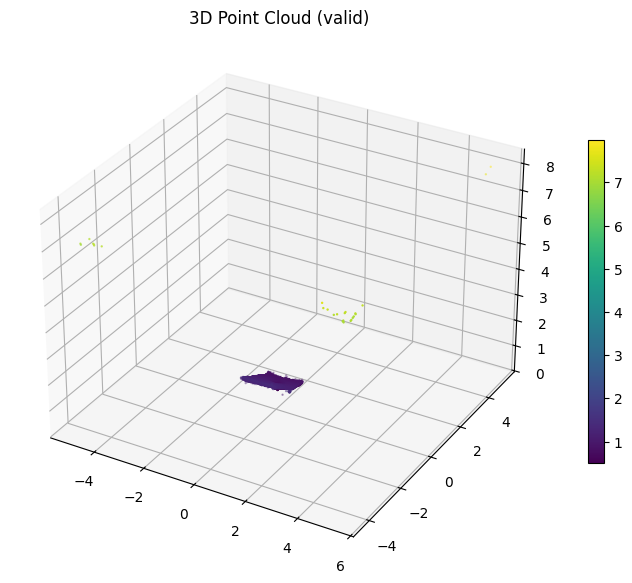

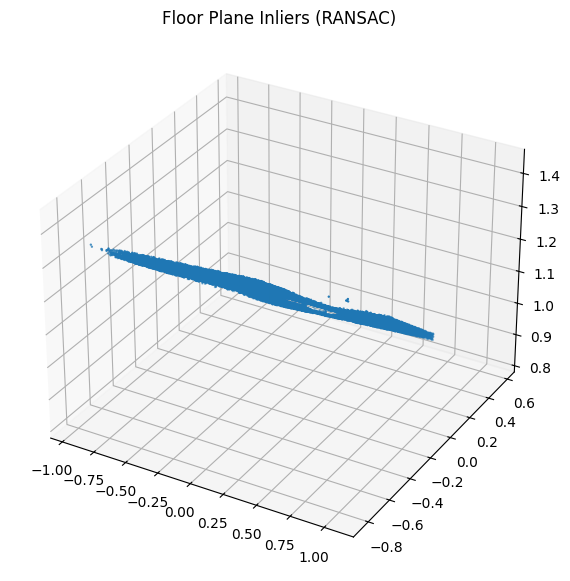

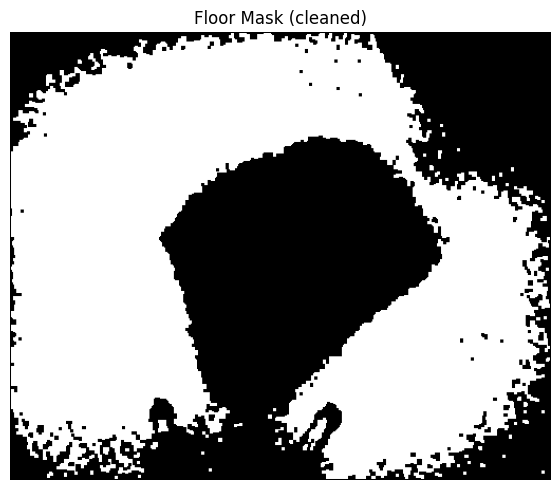

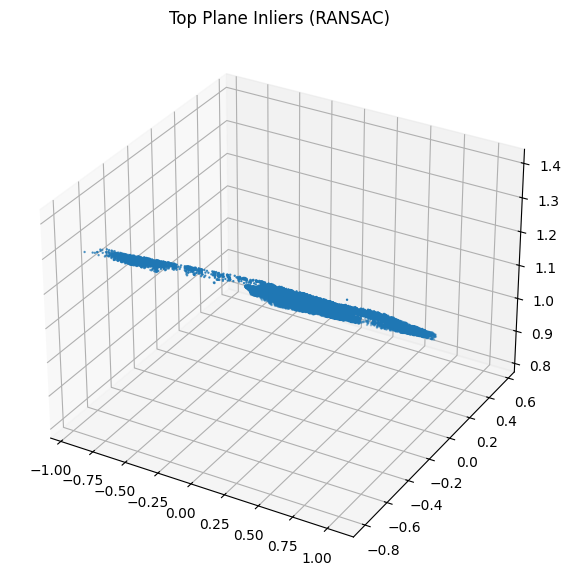

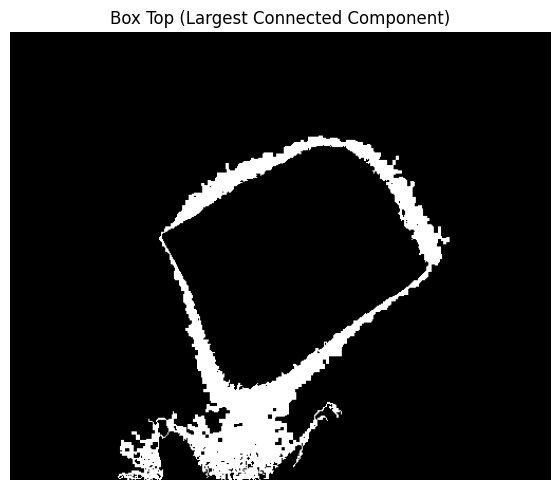

Estimated Box Size:
  Height: 1.30 cm
  Length: 102.84 cm
  Width : 69.15 cm


In [13]:
detect_box_size('/content/data/example1kinect.mat', 'amplitudes1', 'distances1', 'cloud1', 'Estimation of 1st Data Set')
detect_box_size('/content/data/example2kinect.mat', 'amplitudes2', 'distances2', 'cloud2', 'Estimation of 2nd Data Set')
detect_box_size('/content/data/example3kinect.mat', 'amplitudes3', 'distances3', 'cloud3', 'Estimation of 3rd Data Set')
detect_box_size('/content/data/example4kinect.mat', 'amplitudes4', 'distances4', 'cloud4', 'Estimation of 4th Data Set')


In [14]:
def compare_ransac_vs_mlesac(points, thresholds, gamma_factor=1.5, max_iters=800,
                              target_normal=None, min_cos=0.95, seed=0):
    """Run both modes on the same data across several ε values."""
    header = f"{'ε':>7} | {'mode':<7} | {'#inliers':>8} | {'inlier %':>8} | normal n                    |    d"
    print(header)
    print("-" * len(header))
    for eps in thresholds:
        for mode in ("ransac", "mlesac"):
            cfg = RansacConfig(
                threshold=eps, max_iterations=max_iters, seed=seed,
                target_normal=target_normal, min_cos_with_target=min_cos,
                score_mode=mode,
                gamma=gamma_factor * eps if mode == "mlesac" else None,
            )
            res = ransac_plane(points, cfg)
            if res is None:
                print(f"{eps:7.4f} | {mode:<7} |   FAILED")
                continue
            n, d, inl = res
            n_str = f"[{n[0]:+.3f}, {n[1]:+.3f}, {n[2]:+.3f}]"
            pct = 100 * inl.size / points.shape[0]
            print(f"{eps:7.4f} | {mode:<7} | {inl.size:>8d} | {pct:>7.2f}% | {n_str} | {d:+.4f}")
        print()

# --- Run it on the floor data of example 1 ---
import scipy.io
data = scipy.io.loadmat('/content/data/example1kinect.mat')
PC = data['cloud1']
valid_points = PC[PC[:, :, 2] != 0]

compare_ransac_vs_mlesac(
    valid_points,
    thresholds=[0.003, 0.005, 0.01, 0.02, 0.05, 0.1],
)

      ε | mode    | #inliers | inlier % | normal n                    |    d
----------------------------------------------------------------------------
 0.0030 | ransac  |    65266 |   32.31% | [-0.030, +0.588, +0.808] | -0.7285
 0.0030 | mlesac  |    65266 |   32.31% | [-0.030, +0.588, +0.808] | -0.7285

 0.0050 | ransac  |    90493 |   44.80% | [-0.030, +0.588, +0.808] | -0.7287
 0.0050 | mlesac  |    90493 |   44.80% | [-0.030, +0.588, +0.808] | -0.7287

 0.0100 | ransac  |   119034 |   58.93% | [+0.026, -0.588, -0.809] | +0.7279
 0.0100 | mlesac  |   117847 |   58.34% | [+0.029, -0.588, -0.809] | +0.7287

 0.0200 | ransac  |   141299 |   69.95% | [+0.020, -0.586, -0.810] | +0.7271
 0.0200 | mlesac  |   139467 |   69.04% | [+0.023, -0.587, -0.810] | +0.7274

 0.0500 | ransac  |   156077 |   77.26% | [+0.015, -0.587, -0.810] | +0.7239
 0.0500 | mlesac  |   154591 |   76.53% | [-0.016, +0.586, +0.810] | -0.7253

 0.1000 | ransac  |   162539 |   80.46% | [-0.014, +0.591, +0.807] | -0

**Exercise 1.2 — Preemptive RANSAC**

In [15]:
@dataclass
class PreemptiveConfig:
    threshold: float = 0.01           # ε (meters)
    M: int = 500                      # initial number of hypotheses
    B: int = 100                      # batch size before each preemption step
    seed: Optional[int] = 0
    target_normal: Optional[np.ndarray] = None
    min_cos_with_target: float = 0.95
    score_mode: str = "mlesac"        # "ransac" or "mlesac"  (= MSAC scoring)
    gamma: Optional[float] = None     # MLESAC outlier penalty (γ > ε); default 1.5 * threshold
    max_attempt_factor: int = 5       # cap on tries to gather M valid hypotheses


def preemptive_ransac_plane(points: np.ndarray,
                             cfg: PreemptiveConfig
                            ) -> Optional[Tuple[np.ndarray, float, np.ndarray]]:

    N = points.shape[0]
    if N < 3:
        return None

    rng = np.random.default_rng(cfg.seed)
    gamma = cfg.gamma if cfg.gamma is not None else 1.5 * cfg.threshold
    if cfg.score_mode == "mlesac" and gamma <= cfg.threshold:
        raise ValueError(f"MLESAC needs gamma > threshold (got {gamma}, ε={cfg.threshold})")

    # ----  Generate M hypotheses upfront ----
    hyp_n_list, hyp_d_list = [], []
    max_attempts = cfg.M * cfg.max_attempt_factor
    attempts = 0
    while len(hyp_n_list) < cfg.M and attempts < max_attempts:
        attempts += 1
        idx = rng.choice(N, size=3, replace=False)
        model = plane_from_3_points(points[idx[0]], points[idx[1]], points[idx[2]])
        if model is None:
            continue
        n, d = model
        if cfg.target_normal is not None:
            cosang = abs(float(np.dot(n, cfg.target_normal)))
            if cosang < cfg.min_cos_with_target:
                continue
        hyp_n_list.append(n)
        hyp_d_list.append(d)

    if len(hyp_n_list) == 0:
        return None

    M_actual = len(hyp_n_list)
    hyp_n = np.stack(hyp_n_list, axis=0)        # (M, 3)
    hyp_d = np.array(hyp_d_list, dtype=float)   # (M,)

    # ----  Shuffle data points ----
    perm = rng.permutation(N)
    pts_shuf = points[perm]

    # ----  Preemptive scoring loop ----
    alive = np.arange(M_actual)            # indices into hyp_n / hyp_d
    costs = np.zeros(M_actual, dtype=float)

    for i in range(N):
        if alive.size <= 1:
            break

        p = pts_shuf[i]                                          # (3,)
        # |n·p + d| for every alive hypothesis
        dists = np.abs(hyp_n[alive] @ p + hyp_d[alive])          # (|alive|,)

        if cfg.score_mode == "mlesac":
            per_pt = np.where(dists < cfg.threshold, dists, gamma)
        else:  # "ransac": minimize outlier count
            per_pt = np.where(dists < cfg.threshold, 0.0, 1.0)

        costs[alive] += per_pt

        # Preemption check: f(i) using 1-indexed position
        pos = i + 1
        target = int(np.floor(M_actual * (2.0 ** (-(pos // cfg.B)))))
        target = max(1, target)

        if alive.size > target:
            order = np.argsort(costs[alive])      # ascending: lowest cost first
            alive = alive[order[:target]]

    # ----  Pick best survivor ----
    best_idx = alive[np.argmin(costs[alive])]
    n_best, d_best = hyp_n[best_idx], float(hyp_d[best_idx])

    # ----  SVD refinement on the inlier set of the chosen plane ----
    full_dists = point_plane_distances(points, n_best, d_best)
    best_inliers = np.where(full_dists < cfg.threshold)[0]
    if best_inliers.size < 3:
        return n_best, d_best, best_inliers

    pts = points[best_inliers]
    c = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - c, full_matrices=False)
    n_ref = _normalize(Vt[-1])
    d_ref = -float(np.dot(n_ref, c))
    return n_ref, d_ref, best_inliers

In [16]:
import time

def preemptive_param_sweep(points, M_values, B_values, threshold=0.01,
                            score_mode="mlesac", target_normal=None, seed=0):
    """Sweep M and B; report timing, inlier count, and plane parameters."""
    header = f"{'M':>5} | {'B':>4} | {'time (s)':>8} | {'#inliers':>8} | {'inlier %':>8} | n                          |    d"
    print(header)
    print("-" * len(header))
    for M in M_values:
        for B in B_values:
            cfg = PreemptiveConfig(
                threshold=threshold, M=M, B=B, seed=seed,
                target_normal=target_normal, score_mode=score_mode,
            )
            t0 = time.perf_counter()
            res = preemptive_ransac_plane(points, cfg)
            dt = time.perf_counter() - t0
            if res is None:
                print(f"{M:>5} | {B:>4} | {dt:>8.3f} | FAILED")
                continue
            n, d, inl = res
            n_str = f"[{n[0]:+.3f}, {n[1]:+.3f}, {n[2]:+.3f}]"
            pct = 100.0 * inl.size / points.shape[0]
            print(f"{M:>5} | {B:>4} | {dt:>8.3f} | {inl.size:>8d} | {pct:>7.2f}% | {n_str} | {d:+.4f}")
        print()


# --- Run on dataset 1 (floor plane) ---
import scipy.io
data = scipy.io.loadmat('/content/data/example1kinect.mat')
PC = data['cloud1']
valid_points = PC[PC[:, :, 2] != 0]

preemptive_param_sweep(
    valid_points,
    M_values=[20, 50, 100, 200, 500, 1000],
    B_values=[50, 100, 200, 500],
    threshold=0.01,
    score_mode="mlesac",
)

    M |    B | time (s) | #inliers | inlier % | n                          |    d
---------------------------------------------------------------------------------
   20 |   50 |    0.039 |   109312 |   54.11% | [+0.034, -0.590, -0.807] | +0.7291
   20 |  100 |    0.039 |   109312 |   54.11% | [+0.034, -0.590, -0.807] | +0.7291
   20 |  200 |    0.047 |   109312 |   54.11% | [+0.034, -0.590, -0.807] | +0.7291
   20 |  500 |    0.071 |   109312 |   54.11% | [+0.034, -0.590, -0.807] | +0.7291

   50 |   50 |    0.042 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289
   50 |  100 |    0.045 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289
   50 |  200 |    0.055 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289
   50 |  500 |    0.087 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289

  100 |   50 |    0.050 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289
  100 |  100 |    0.051 |   118307 |   58.57% | [+0.024, -0.585, -0.811] | +0.7289
  10

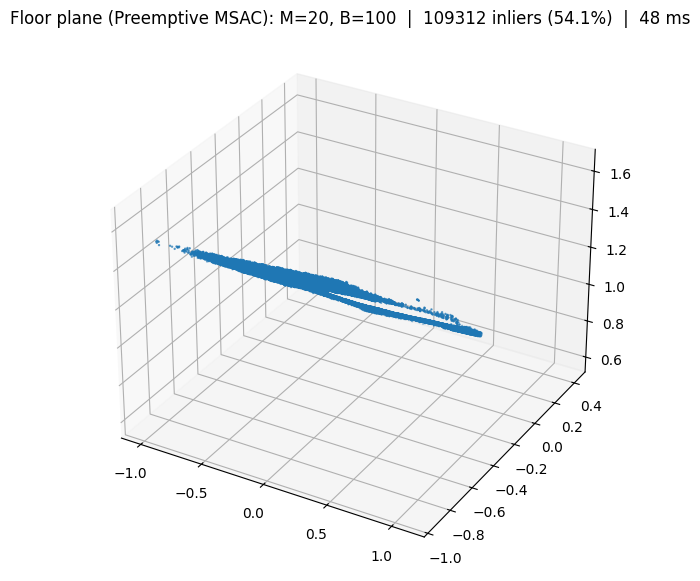

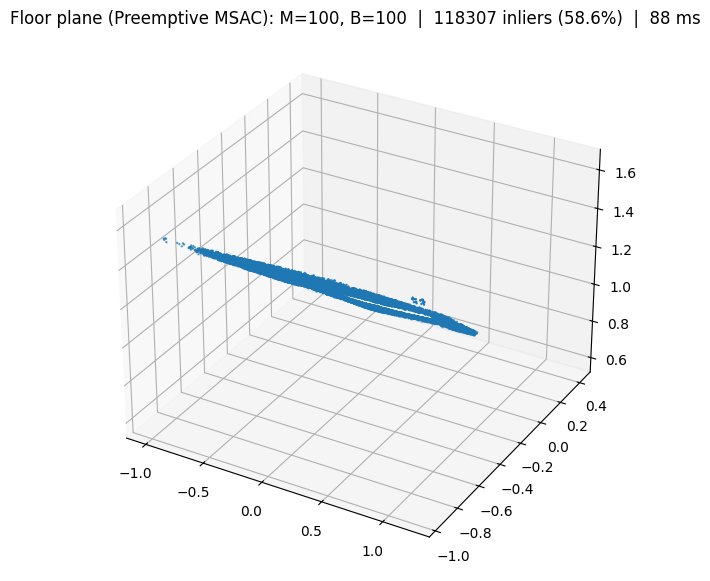

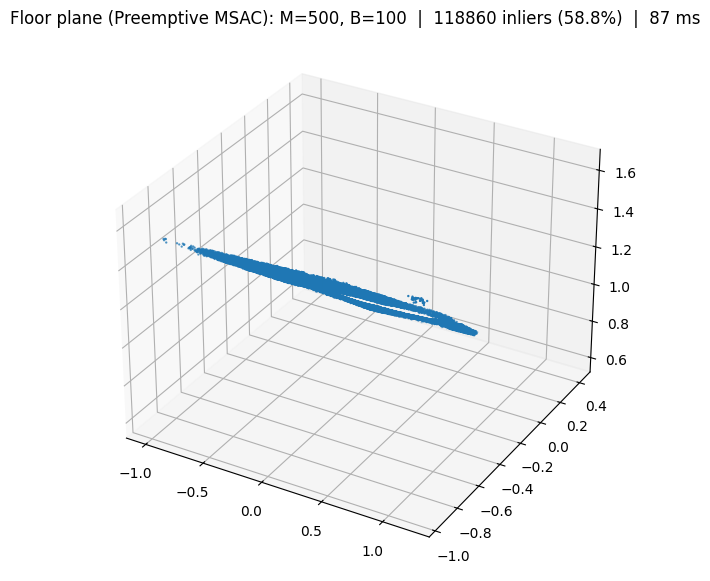

In [17]:
def visualize_preemptive_for_M(points, M_values, threshold=0.01, B=100,
                                score_mode="mlesac", target_normal=None,
                                title_prefix="Preemptive RANSAC"):
    """Run preemptive RANSAC for a few M values and scatter-plot the inliers each time."""
    for M in M_values:
        cfg = PreemptiveConfig(
            threshold=threshold, M=M, B=B, seed=0,
            target_normal=target_normal, score_mode=score_mode,
        )
        t0 = time.perf_counter()
        res = preemptive_ransac_plane(points, cfg)
        dt = time.perf_counter() - t0
        if res is None:
            print(f"M={M}: failed")
            continue
        n, d, inl = res
        pct = 100.0 * inl.size / points.shape[0]
        title = f"{title_prefix}: M={M}, B={B}  |  {inl.size} inliers ({pct:.1f}%)  |  {dt*1000:.0f} ms"
        scatter3(points[inl], title)


# Three time budgets: small / medium / large
visualize_preemptive_for_M(
    valid_points,
    M_values=[20, 100, 500],   # small, medium, large
    threshold=0.01, B=100,
    score_mode="mlesac",
    title_prefix="Floor plane (Preemptive MSAC)",
)